In [ ]:
# =============================================================================
# Clasificacion Gaussian Naive Bayes - Dataset ENDES 2024 RECH6 (Anemia Infantil)
# Script completo end-to-end sin uso de 'def' fuera de la clase
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

In [ ]:
# =============================================================================
# CLASE: GaussianNaiveBayes (implementacion desde cero)
# =============================================================================

class GaussianNaiveBayes:
    """
    Clasificador Gaussian Naive Bayes implementado desde cero.

    Atributos
    ---------
    clases_ : array
        Etiquetas de clase unicas detectadas en el entrenamiento.
    log_priors_ : dict
        Logaritmo de la probabilidad a priori de cada clase.
    medias_ : dict
        Media de cada feature por clase.
    varianzas_ : dict
        Varianza de cada feature por clase (con suavizado epsilon).
    epsilon_ : float
        Valor de suavizado para evitar varianza cero.
    """

    def __init__(self, epsilon=1e-9):
        """
        Inicializa el clasificador.

        Parametros
        ----------
        epsilon : float
            Termino de suavizado sumado a la varianza para evitar division
            por cero y logaritmo de cero.
        """
        self.epsilon_ = epsilon
        self.clases_ = None
        self.log_priors_ = {}
        self.medias_ = {}
        self.varianzas_ = {}

    def fit(self, X, y):
        """
        Entrena el modelo calculando priors, medias y varianzas por clase.

        Parametros
        ----------
        X : np.ndarray, shape (n_muestras, n_features)
            Matriz de features de entrenamiento.
        y : np.ndarray, shape (n_muestras,)
            Vector de etiquetas de clase.

        Retorna
        -------
        self
        """
        X = np.array(X)
        y = np.array(y)
        self.clases_ = np.unique(y)
        n_total = len(y)

        for c in self.clases_:
            X_c = X[y == c]
            n_c = len(X_c)
            self.log_priors_[c] = np.log(n_c / n_total)
            self.medias_[c] = X_c.mean(axis=0)
            self.varianzas_[c] = X_c.var(axis=0) + self.epsilon_

        return self

    def _log_gaussian(self, X, clase):
        """
        Calcula el log de la verosimilitud gaussiana para cada feature.

        Parametros
        ----------
        X : np.ndarray, shape (n_muestras, n_features)
            Datos de entrada.
        clase : str o int
            Etiqueta de la clase para la que se calcula la verosimilitud.

        Retorna
        -------
        np.ndarray, shape (n_muestras,)
            Suma del log de la densidad gaussiana sobre todas las features.
        """
        mu = self.medias_[clase]
        sigma2 = self.varianzas_[clase]
        log_exp = -0.5 * np.sum(((X - mu) ** 2) / sigma2, axis=1)
        log_norm = -0.5 * np.sum(np.log(2 * np.pi * sigma2))
        return log_norm + log_exp

    def predict_proba(self, X):
        """
        Calcula probabilidades posteriores para cada clase.

        Parametros
        ----------
        X : np.ndarray, shape (n_muestras, n_features)
            Datos de entrada.

        Retorna
        -------
        np.ndarray, shape (n_muestras, n_clases)
            Probabilidades por clase (normalizadas).
        """
        X = np.array(X)
        log_posteriors = np.column_stack([
            self.log_priors_[c] + self._log_gaussian(X, c)
            for c in self.clases_
        ])
        # Normalizacion numericamente estable via log-sum-exp
        log_max = log_posteriors.max(axis=1, keepdims=True)
        log_sum = np.log(
            np.exp(log_posteriors - log_max).sum(axis=1, keepdims=True)
        ) + log_max
        return np.exp(log_posteriors - log_sum)

    def predict(self, X):
        """
        Predice la clase con mayor probabilidad posterior.

        Parametros
        ----------
        X : np.ndarray, shape (n_muestras, n_features)
            Datos de entrada.

        Retorna
        -------
        np.ndarray, shape (n_muestras,)
            Etiqueta de clase predicha para cada muestra.
        """
        proba = self.predict_proba(X)
        indices = np.argmax(proba, axis=1)
        return self.clases_[indices]

In [ ]:
# =============================================================================
# 1. CARGA DEL DATASET (ENDES 2024 - Cuestionario Individual RECH6)
# =============================================================================

print("=" * 70)
print("CARGA DEL DATASET ENDES 2024 - RECH6 (ANEMIA INFANTIL)")
print("=" * 70)

df = pd.read_excel('/content/RECH6_2024.xlsx')

print(f"\nShape del dataset original: {df.shape}")
print(f"\nColumnas:\n{df.columns.tolist()}")

# HC57A: Nivel de Anemia (NUEVA DIRECTRIZ OMS 2024 / RM 251-2024-MINSA)
#   1 Grave | 2 Moderada | 3 Leve | 4 Sin anemia | 9 No aplica / sin dato
print(f"\nDistribucion original de HC57A (Nivel de Anemia):\n{df['HC57A'].value_counts(dropna=False)}")

CARGA DEL DATASET ENDES 2024 - RECH6 (ANEMIA INFANTIL)

Shape del dataset original: (20290, 43)

Columnas:
['ID1', 'HHID', 'HC0', 'HC1', 'HC2', 'HC3', 'HC4', 'HC5', 'HC6', 'HC7', 'HC8', 'HC9', 'HC10', 'HC11', 'HC12', 'HC13', 'HC15', 'HC16', 'HC19', 'HC27', 'HC30', 'HC31', 'HC32', 'HC33', 'HC51', 'HC52', 'HC53', 'HC55', 'HC56', 'HC56A', 'HC57', 'HC57A', 'HC58', 'HC60', 'HC61', 'HC62', 'HC63', 'HC64', 'HC68', 'HC70', 'HC71', 'HC72', 'HC73']

Distribucion original de HC57A (Nivel de Anemia):
HC57A
4    12598
3     4371
9     1932
2     1371
1       18
Name: count, dtype: int64


In [ ]:
# =============================================================================
# 2. FILTRADO DE CASOS VALIDOS Y CREACION DEL TARGET BINARIO
# =============================================================================

print("\n" + "=" * 70)
print("FILTRADO DE CASOS VALIDOS")
print("=" * 70)

# Nos quedamos solo con ninos con nivel de anemia efectivamente medido (1 a 4)
df = df[df["HC57A"].isin([1, 2, 3, 4])].copy()
print(f"\nCasos con HC57A valido (1:4): {df.shape[0]}")

# Codigos de valor perdido / fuera de rango en variables antropometricas
# (9996, 9997, 9998, 9999 = altura fuera de limites, edad fuera de limites, casos marcados)
COLS_ANTROPOMETRICAS = ["HC2", "HC3", "HC70", "HC71", "HC72", "HC73"]
for col in COLS_ANTROPOMETRICAS:
    df = df[df[col] < 9000]

# HC61: Nivel educativo de la madre -> nos quedamos solo con codigos validos (0:3)
df = df[df["HC61"].isin([0, 1, 2, 3])].copy()

print(f"Casos finales tras eliminar valores perdidos / fuera de rango: {df.shape[0]}")

# Escalado de variables almacenadas con 1 decimal implicito (segun diccionario RECH6)
df["Peso_kg"] = df["HC2"] / 10.0          # HC2: peso en kg (1 dec.)
df["Talla_cm"] = df["HC3"] / 10.0         # HC3: talla en cm (1 dec.)
df["TallaEdad_DE"] = df["HC70"] / 10.0    # HC70: Talla/Edad DE (OMS)
df["PesoEdad_DE"] = df["HC71"] / 10.0     # HC71: Peso/Edad DE (OMS)
df["PesoTalla_DE"] = df["HC72"] / 10.0    # HC72: Peso/Talla DE (OMS)
df["IMC_DE"] = df["HC73"] / 10.0          # HC73: IMC DE (OMS)
df["Edad_meses"] = df["HC1"]              # HC1: edad en meses (0:59)

# Variable objetivo binaria: Con Anemia (Grave/Moderada/Leve) vs Sin Anemia
df["NivelAnemia"] = np.where(df["HC57A"] == 4, "Sin_Anemia", "Con_Anemia")

# Variables categoricas legibles
df["Sexo"] = df["HC27"].map({1: "Hombre", 2: "Mujer"})
df["EducMadre"] = df["HC61"].map({
    0: "Sin_educacion", 1: "Primaria", 2: "Secundaria", 3: "Superior"
})

print(f"\nDistribucion del target binario NivelAnemia:\n{df['NivelAnemia'].value_counts()}")
print(f"\nProporciones:\n{df['NivelAnemia'].value_counts(normalize=True).round(4)}")

COLS_NUMERICAS = ["Edad_meses", "Peso_kg", "Talla_cm",
                  "TallaEdad_DE", "PesoEdad_DE", "PesoTalla_DE", "IMC_DE"]
COLS_CATEGORICAS = ["Sexo", "EducMadre"]

print(f"\nDistribucion de variables categoricas:")
for col in COLS_CATEGORICAS:
    print(f"\n  {col}:\n{df[col].value_counts()}")

print(f"\nEstadisticas descriptivas (numericas):\n{df[COLS_NUMERICAS].describe()}")


FILTRADO DE CASOS VALIDOS

Casos con HC57A valido (1:4): 18358
Casos finales tras eliminar valores perdidos / fuera de rango: 17798

Distribucion del target binario NivelAnemia:
NivelAnemia
Sin_Anemia    12189
Con_Anemia     5609
Name: count, dtype: int64

Proporciones:
NivelAnemia
Sin_Anemia    0.6849
Con_Anemia    0.3151
Name: proportion, dtype: float64

Distribucion de variables categoricas:

  Sexo:
Sexo
Hombre    9035
Mujer     8763
Name: count, dtype: int64

  EducMadre:
EducMadre
Secundaria       12144
Superior          2783
Primaria          2693
Sin_educacion      178
Name: count, dtype: int64

Estadisticas descriptivas (numericas):
         Edad_meses       Peso_kg      Talla_cm  TallaEdad_DE   PesoEdad_DE  \
count  17798.000000  17798.000000  17798.000000  17798.000000  17798.000000   
mean      32.293741     13.229655     88.717553     -8.772907     -1.412833   
std       15.620960      3.459782     11.844468     10.132820     10.405833   
min        6.000000      4.900000

In [ ]:
# =============================================================================
# 3. PREPROCESAMIENTO: ONE-HOT ENCODING + ESCALADO
# =============================================================================

print("\n" + "=" * 70)
print("PREPROCESAMIENTO")
print("=" * 70)

# One-Hot Encoding de las categoricas
dummies = pd.get_dummies(df[COLS_CATEGORICAS], drop_first=False)
print(f"\nColumnas generadas por One-Hot Encoding:\n{dummies.columns.tolist()}")
print(f"Shape dummies: {dummies.shape}")

X_num = df[COLS_NUMERICAS].copy()
y = df["NivelAnemia"].values

# Escalado de features numericas
scaler = StandardScaler()


PREPROCESAMIENTO

Columnas generadas por One-Hot Encoding:
['Sexo_Hombre', 'Sexo_Mujer', 'EducMadre_Primaria', 'EducMadre_Secundaria', 'EducMadre_Sin_educacion', 'EducMadre_Superior']
Shape dummies: (17798, 6)


In [ ]:
# =============================================================================
# 4. TRAIN/TEST SPLIT ESTRATIFICADO
# =============================================================================

print("\n" + "=" * 70)
print("TRAIN / TEST SPLIT ESTRATIFICADO (80/20)")
print("=" * 70)

# Combinar numericas + dummies ANTES de dividir para aplicar scaler correctamente
X_full = pd.concat([X_num.reset_index(drop=True),
                    dummies.reset_index(drop=True)], axis=1)

# Indices de columnas numericas en X_full
idx_num = list(range(len(COLS_NUMERICAS)))

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y, test_size=0.20, random_state=42, stratify=y
)

# Escalar SOLO las columnas numericas (fit en train, transform en ambos)
X_train_arr = X_train_full.values.copy().astype(float)
X_test_arr  = X_test_full.values.copy().astype(float)

scaler.fit(X_train_arr[:, idx_num])
X_train_arr[:, idx_num] = scaler.transform(X_train_arr[:, idx_num])
X_test_arr[:, idx_num]  = scaler.transform(X_test_arr[:, idx_num])

print(f"\nTrain shape: {X_train_arr.shape}")
print(f"Test  shape: {X_test_arr.shape}")
print(f"\nDistribucion train:\n{pd.Series(y_train).value_counts()}")
print(f"\nDistribucion test:\n{pd.Series(y_test).value_counts()}")
print(f"\nColumnas finales del modelo ({X_full.shape[1]} total):")
print(X_full.columns.tolist())


TRAIN / TEST SPLIT ESTRATIFICADO (80/20)

Train shape: (14238, 13)
Test  shape: (3560, 13)

Distribucion train:
Sin_Anemia    9751
Con_Anemia    4487
Name: count, dtype: int64

Distribucion test:
Sin_Anemia    2438
Con_Anemia    1122
Name: count, dtype: int64

Columnas finales del modelo (13 total):
['Edad_meses', 'Peso_kg', 'Talla_cm', 'TallaEdad_DE', 'PesoEdad_DE', 'PesoTalla_DE', 'IMC_DE', 'Sexo_Hombre', 'Sexo_Mujer', 'EducMadre_Primaria', 'EducMadre_Secundaria', 'EducMadre_Sin_educacion', 'EducMadre_Superior']


In [ ]:
# =============================================================================
# 5. ENTRENAMIENTO: IMPLEMENTACION MANUAL
# =============================================================================

print("\n" + "=" * 70)
print("ENTRENAMIENTO: GAUSSIAN NAIVE BAYES MANUAL")
print("=" * 70)

gnb_manual = GaussianNaiveBayes(epsilon=1e-9)
gnb_manual.fit(X_train_arr, y_train)

y_pred_train_manual = gnb_manual.predict(X_train_arr)
y_pred_test_manual  = gnb_manual.predict(X_test_arr)

acc_train_manual = accuracy_score(y_train, y_pred_train_manual)
acc_test_manual  = accuracy_score(y_test,  y_pred_test_manual)

print(f"\nAccuracy Train (manual): {acc_train_manual:.4f}")
print(f"Accuracy Test  (manual): {acc_test_manual:.4f}")
print(f"\nClases del modelo: {gnb_manual.clases_}")
print(f"\nLog-priors por clase:")
for c, lp in gnb_manual.log_priors_.items():
    print(f"  {c}: {lp:.4f}  (prior = {np.exp(lp):.4f})")

print(f"\nClassification Report (manual - Test):")
print(classification_report(y_test, y_pred_test_manual))

cm_manual = confusion_matrix(y_test, y_pred_test_manual,
                              labels=gnb_manual.clases_)
print(f"Confusion Matrix (manual):\n{cm_manual}")


ENTRENAMIENTO: GAUSSIAN NAIVE BAYES MANUAL

Accuracy Train (manual): 0.6589
Accuracy Test  (manual): 0.6517

Clases del modelo: ['Con_Anemia' 'Sin_Anemia']

Log-priors por clase:
  Con_Anemia: -1.1547  (prior = 0.3151)
  Sin_Anemia: -0.3785  (prior = 0.6849)

Classification Report (manual - Test):
              precision    recall  f1-score   support

  Con_Anemia       0.44      0.35      0.39      1122
  Sin_Anemia       0.73      0.79      0.76      2438

    accuracy                           0.65      3560
   macro avg       0.58      0.57      0.57      3560
weighted avg       0.63      0.65      0.64      3560

Confusion Matrix (manual):
[[ 396  726]
 [ 514 1924]]


In [ ]:
# =============================================================================
# 6. ENTRENAMIENTO: SKLEARN GaussianNB
# =============================================================================

print("\n" + "=" * 70)
print("ENTRENAMIENTO: SKLEARN GaussianNB")
print("=" * 70)

gnb_sklearn = GaussianNB()
gnb_sklearn.fit(X_train_arr, y_train)

y_pred_train_sk = gnb_sklearn.predict(X_train_arr)
y_pred_test_sk  = gnb_sklearn.predict(X_test_arr)

acc_train_sk = accuracy_score(y_train, y_pred_train_sk)
acc_test_sk  = accuracy_score(y_test,  y_pred_test_sk)

print(f"\nAccuracy Train (sklearn): {acc_train_sk:.4f}")
print(f"Accuracy Test  (sklearn): {acc_test_sk:.4f}")

print(f"\nClassification Report (sklearn - Test):")
print(classification_report(y_test, y_pred_test_sk))

cm_sklearn = confusion_matrix(y_test, y_pred_test_sk,
                               labels=gnb_manual.clases_)
print(f"Confusion Matrix (sklearn):\n{cm_sklearn}")


ENTRENAMIENTO: SKLEARN GaussianNB

Accuracy Train (sklearn): 0.6589
Accuracy Test  (sklearn): 0.6517

Classification Report (sklearn - Test):
              precision    recall  f1-score   support

  Con_Anemia       0.44      0.35      0.39      1122
  Sin_Anemia       0.73      0.79      0.76      2438

    accuracy                           0.65      3560
   macro avg       0.58      0.57      0.57      3560
weighted avg       0.63      0.65      0.64      3560

Confusion Matrix (sklearn):
[[ 396  726]
 [ 514 1924]]


In [ ]:
# =============================================================================
# 7. VERIFICACION DE CONCORDANCIA
# =============================================================================

print("\n" + "=" * 70)
print("VERIFICACION: MANUAL vs SKLEARN")
print("=" * 70)

coincidencias = np.sum(y_pred_test_manual == y_pred_test_sk)
total_test = len(y_test)
print(f"\nPredicciones identicas en test: {coincidencias}/{total_test} "
      f"({coincidencias/total_test*100:.1f}%)")
print(f"Diferencia de accuracy (test):  {abs(acc_test_manual - acc_test_sk):.6f}")

if abs(acc_test_manual - acc_test_sk) < 0.01:
    print("RESULTADO: Ambas implementaciones coinciden (diferencia < 1%).")
else:
    print("RESULTADO: Existe diferencia entre implementaciones (revisar epsilon).")


VERIFICACION: MANUAL vs SKLEARN

Predicciones identicas en test: 3560/3560 (100.0%)
Diferencia de accuracy (test):  0.000000
RESULTADO: Ambas implementaciones coinciden (diferencia < 1%).



GENERANDO VISUALIZACIONES


/tmp/ipykernel_1998/3068442564.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["NivelAnemia"], palette=["#E53935", "#2196F3"],


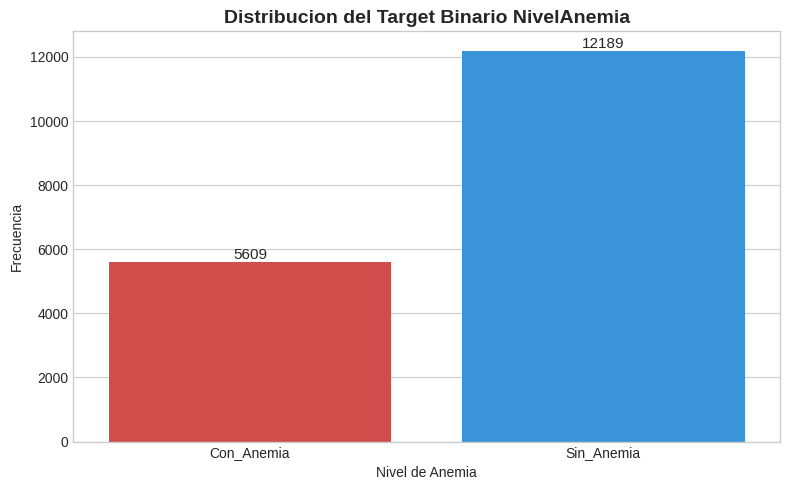

  -> Grafico 01 guardado.


/tmp/ipykernel_1998/3068442564.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="NivelAnemia", y="Hemoglobina_gdl", data=df_temp_hb,


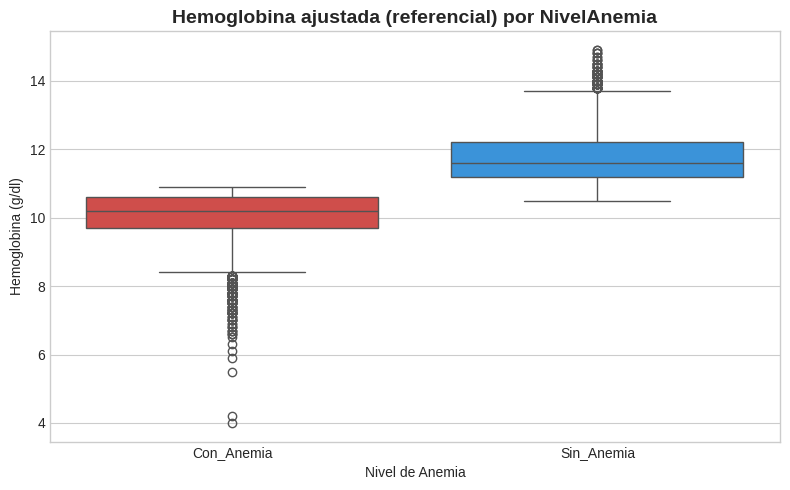

  -> Grafico 02 guardado (solo referencial; no se usa como feature del modelo).


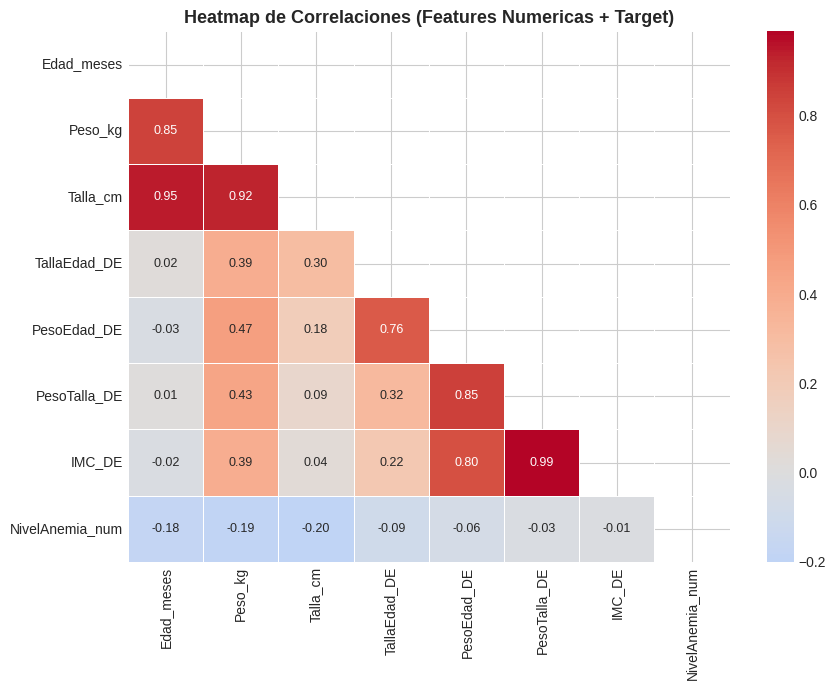

  -> Grafico 03 guardado.


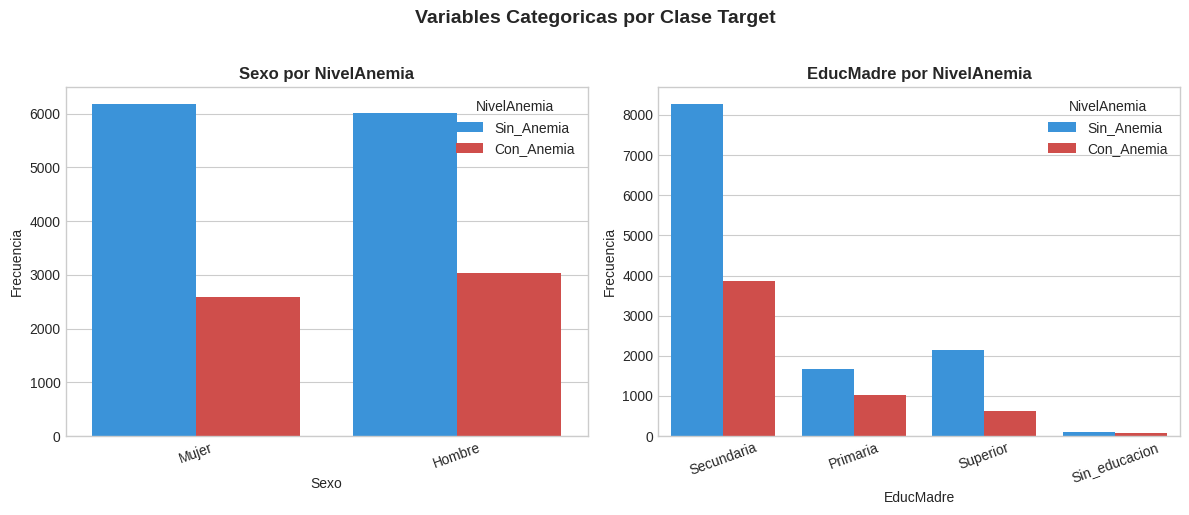

  -> Grafico 04 guardado.


/tmp/ipykernel_1998/3068442564.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="NivelAnemia", y=feat, data=df,
/tmp/ipykernel_1998/3068442564.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="NivelAnemia", y=feat, data=df,
/tmp/ipykernel_1998/3068442564.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="NivelAnemia", y=feat, data=df,


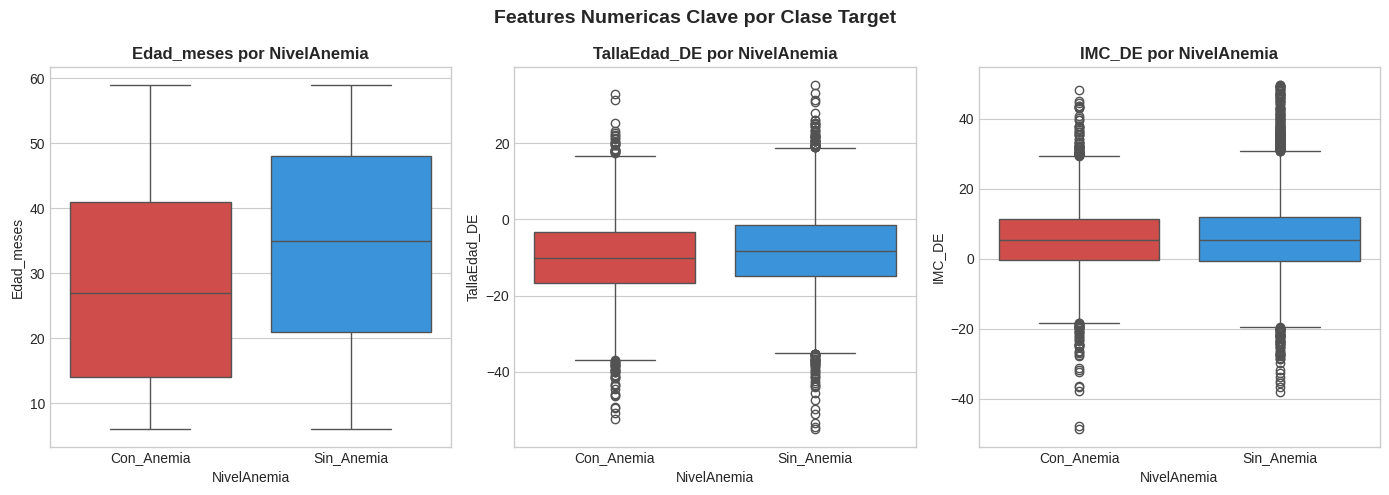

  -> Grafico 05 guardado.


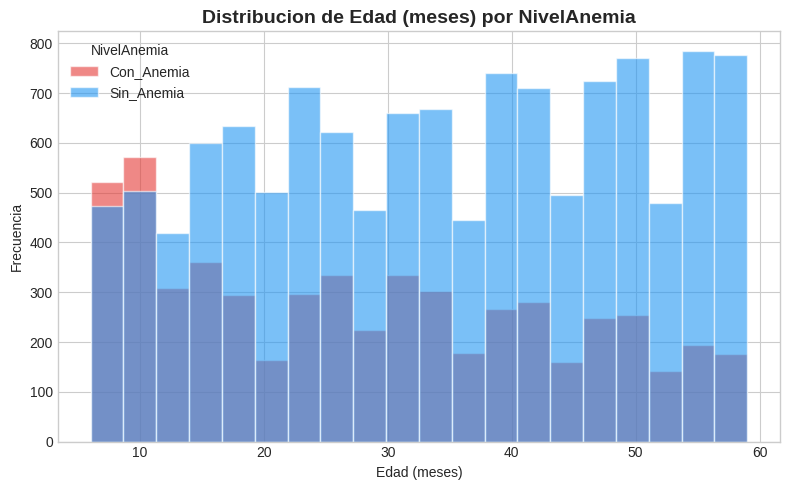

  -> Grafico 06 guardado.


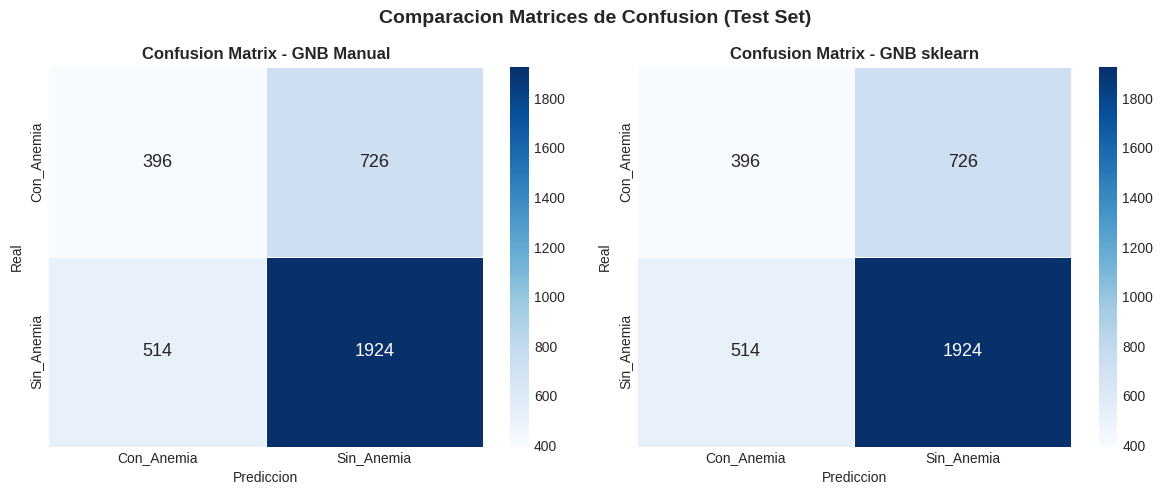

  -> Grafico 07 guardado.


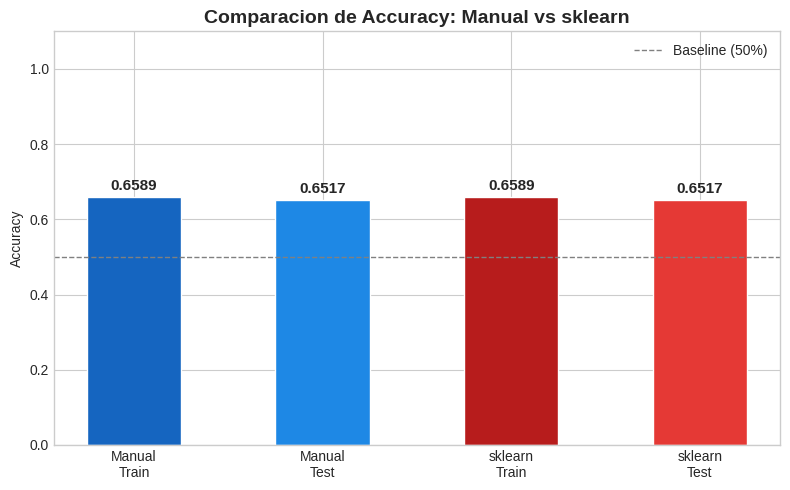

  -> Grafico 08 guardado.


In [ ]:
# =============================================================================
# 8. VISUALIZACIONES
# =============================================================================

print("\n" + "=" * 70)
print("GENERANDO VISUALIZACIONES")
print("=" * 70)

plt.style.use("seaborn-v0_8-whitegrid")
FIGSIZE_NORMAL = (8, 5)
FIGSIZE_WIDE   = (14, 5)

# --- 8.1 Distribucion del target binario ---
fig, ax = plt.subplots(figsize=FIGSIZE_NORMAL)
sns.countplot(x=df["NivelAnemia"], palette=["#E53935", "#2196F3"],
              order=["Con_Anemia", "Sin_Anemia"], ax=ax)
ax.set_title("Distribucion del Target Binario NivelAnemia", fontsize=14, fontweight="bold")
ax.set_xlabel("Nivel de Anemia")
ax.set_ylabel("Frecuencia")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=11)
plt.tight_layout()
plt.savefig("01_distribucion_target.png", dpi=150)
plt.show()
print("  -> Grafico 01 guardado.")

# --- 8.2 Boxplot Hemoglobina ajustada (referencial, no usada como feature) por NivelAnemia ---
df_temp_hb = df[["HC56A", "NivelAnemia"]].copy()
df_temp_hb["Hemoglobina_gdl"] = df_temp_hb["HC56A"] / 10.0
fig, ax = plt.subplots(figsize=FIGSIZE_NORMAL)
sns.boxplot(x="NivelAnemia", y="Hemoglobina_gdl", data=df_temp_hb,
            palette=["#E53935", "#2196F3"], order=["Con_Anemia", "Sin_Anemia"], ax=ax)
ax.set_title("Hemoglobina ajustada (referencial) por NivelAnemia", fontsize=14, fontweight="bold")
ax.set_xlabel("Nivel de Anemia")
ax.set_ylabel("Hemoglobina (g/dl)")
plt.tight_layout()
plt.savefig("02_boxplot_hemoglobina_referencial.png", dpi=150)
plt.show()
print("  -> Grafico 02 guardado (solo referencial; no se usa como feature del modelo).")

# --- 8.3 Heatmap de correlaciones de features numericas ---
df_corr = df[COLS_NUMERICAS].copy()
df_corr["NivelAnemia_num"] = (df["NivelAnemia"] == "Con_Anemia").astype(int)

fig, ax = plt.subplots(figsize=(9, 7))
corr_matrix = df_corr.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5,
            annot_kws={"size": 9}, ax=ax)
ax.set_title("Heatmap de Correlaciones (Features Numericas + Target)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("03_heatmap_correlaciones.png", dpi=150)
plt.show()
print("  -> Grafico 03 guardado.")

# --- 8.4 Categoricas por NivelAnemia ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, col in enumerate(COLS_CATEGORICAS):
    sns.countplot(x=col, hue="NivelAnemia", data=df,
                  palette={"Con_Anemia": "#E53935", "Sin_Anemia": "#2196F3"},
                  ax=axes[i])
    axes[i].set_title(f"{col} por NivelAnemia", fontsize=12, fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")
    axes[i].tick_params(axis="x", rotation=20)
    axes[i].legend(title="NivelAnemia")
plt.suptitle("Variables Categoricas por Clase Target", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("04_categoricas_por_target.png", dpi=150, bbox_inches="tight")
plt.show()
print("  -> Grafico 04 guardado.")

# --- 8.5 Boxplots de features numericas clave por NivelAnemia ---
features_box = ["Edad_meses", "TallaEdad_DE", "IMC_DE"]
fig, axes = plt.subplots(1, 3, figsize=FIGSIZE_WIDE)
for i, feat in enumerate(features_box):
    sns.boxplot(x="NivelAnemia", y=feat, data=df,
                palette={"Con_Anemia": "#E53935", "Sin_Anemia": "#2196F3"},
                order=["Con_Anemia", "Sin_Anemia"], ax=axes[i])
    axes[i].set_title(f"{feat} por NivelAnemia", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("NivelAnemia")
    axes[i].set_ylabel(feat)
plt.suptitle("Features Numericas Clave por Clase Target", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("05_boxplots_features_numericas.png", dpi=150)
plt.show()
print("  -> Grafico 05 guardado.")

# --- 8.6 Histograma de edad por clase ---
fig, ax = plt.subplots(figsize=FIGSIZE_NORMAL)
for clase, color in zip(["Con_Anemia", "Sin_Anemia"], ["#E53935", "#2196F3"]):
    subset = df[df["NivelAnemia"] == clase]["Edad_meses"]
    ax.hist(subset, bins=20, alpha=0.6, label=clase, color=color, edgecolor="white")
ax.set_title("Distribucion de Edad (meses) por NivelAnemia", fontsize=14, fontweight="bold")
ax.set_xlabel("Edad (meses)")
ax.set_ylabel("Frecuencia")
ax.legend(title="NivelAnemia")
plt.tight_layout()
plt.savefig("06_histograma_edad.png", dpi=150)
plt.show()
print("  -> Grafico 06 guardado.")

# --- 8.7 Matrices de confusion lado a lado ---
etiquetas = list(gnb_manual.clases_)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax_cm, cm, titulo in zip(
    axes,
    [cm_manual, cm_sklearn],
    ["GNB Manual", "GNB sklearn"]
):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=etiquetas, yticklabels=etiquetas,
                linewidths=0.5, ax=ax_cm, annot_kws={"size": 13})
    ax_cm.set_title(f"Confusion Matrix - {titulo}", fontsize=12, fontweight="bold")
    ax_cm.set_xlabel("Prediccion")
    ax_cm.set_ylabel("Real")

plt.suptitle("Comparacion Matrices de Confusion (Test Set)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("07_confusion_matrices.png", dpi=150)
plt.show()
print("  -> Grafico 07 guardado.")

# --- 8.8 Comparacion de accuracy ---
fig, ax = plt.subplots(figsize=(8, 5))
modelos   = ["Manual\nTrain", "Manual\nTest", "sklearn\nTrain", "sklearn\nTest"]
accuracys = [acc_train_manual, acc_test_manual, acc_train_sk, acc_test_sk]
colores   = ["#1565C0", "#1E88E5", "#B71C1C", "#E53935"]
bars = ax.bar(modelos, accuracys, color=colores, edgecolor="white", width=0.5)
ax.set_ylim(0, 1.1)
ax.set_title("Comparacion de Accuracy: Manual vs sklearn", fontsize=14, fontweight="bold")
ax.set_ylabel("Accuracy")
for bar, val in zip(bars, accuracys):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Baseline (50%)")
ax.legend()
plt.tight_layout()
plt.savefig("08_comparacion_accuracy.png", dpi=150)
plt.show()
print("  -> Grafico 08 guardado.")

In [ ]:
# =============================================================================
# 9. PREDICCION DE MUESTRAS NUEVAS
# =============================================================================

print("\n" + "=" * 70)
print("PREDICCION DE MUESTRAS NUEVAS")
print("=" * 70)

# Definir 4 ninos inventados con valores plausibles (sin usar hemoglobina)
nuevos_ninos_raw = pd.DataFrame({
    "Edad_meses":   [6.0,   18.0,  36.0,  50.0],
    "Peso_kg":      [7.5,   10.2,  14.0,  16.8],
    "Talla_cm":     [66.0,  78.0,  92.0,  102.0],
    "TallaEdad_DE": [-1.0,  -2.3,  0.2,   -0.5],
    "PesoEdad_DE":  [-0.8,  -1.9,  0.1,   -0.3],
    "PesoTalla_DE": [-0.3,  -1.0,  0.0,   0.2],
    "IMC_DE":       [-0.2,  -0.9,  0.1,   0.3],
    "Sexo":         ["Hombre", "Mujer", "Hombre", "Mujer"],
    "EducMadre":    ["Secundaria", "Primaria", "Superior", "Sin_educacion"],
})

print("\nNinos nuevos (valores crudos):")
print(nuevos_ninos_raw.to_string(index=False))

# One-Hot Encoding igual que en el entrenamiento
dummies_nuevas = pd.get_dummies(nuevos_ninos_raw[COLS_CATEGORICAS], drop_first=False)

# Alinear columnas con las del entrenamiento (agrega ceros si falta alguna)
dummies_nuevas = dummies_nuevas.reindex(columns=dummies.columns, fill_value=0)

X_nuevas_num = nuevos_ninos_raw[COLS_NUMERICAS].values.astype(float)
X_nuevas_cat = dummies_nuevas.values.astype(float)

# Combinar y escalar numericas
X_nuevas_num_scaled = scaler.transform(X_nuevas_num)
X_nuevas = np.concatenate([X_nuevas_num_scaled, X_nuevas_cat], axis=1)

# Prediccion con modelo manual
clases_pred_manual = gnb_manual.predict(X_nuevas)
probas_manual      = gnb_manual.predict_proba(X_nuevas)

print("\nResultados de prediccion (modelo manual):")
print(f"{'Nino':<8} {'Clase Predicha':<16} ", end="")
for c in gnb_manual.clases_:
    print(f"{'P('+c+')':<16}", end="")
print()
print("-" * 65)

for i in range(len(nuevos_ninos_raw)):
    clase_pred = clases_pred_manual[i]
    proba_max  = probas_manual[i].max()
    print(f"{'Nino '+str(i+1):<8} {clase_pred:<16} ", end="")
    for p in probas_manual[i]:
        print(f"{p:<16.4f}", end="")
    print(f"  [Confianza: {proba_max:.2%}]")

# Prediccion con sklearn para verificacion
clases_pred_sk = gnb_sklearn.predict(X_nuevas)
print(f"\nVerificacion sklearn: {clases_pred_sk.tolist()}")
print(f"Verificacion manual:  {clases_pred_manual.tolist()}")


PREDICCION DE MUESTRAS NUEVAS

Ninos nuevos (valores crudos):
 Edad_meses  Peso_kg  Talla_cm  TallaEdad_DE  PesoEdad_DE  PesoTalla_DE  IMC_DE   Sexo     EducMadre
        6.0      7.5      66.0          -1.0         -0.8          -0.3    -0.2 Hombre    Secundaria
       18.0     10.2      78.0          -2.3         -1.9          -1.0    -0.9  Mujer      Primaria
       36.0     14.0      92.0           0.2          0.1           0.0     0.1 Hombre      Superior
       50.0     16.8     102.0          -0.5         -0.3           0.2     0.3  Mujer Sin_educacion

Resultados de prediccion (modelo manual):
Nino     Clase Predicha   P(Con_Anemia)   P(Sin_Anemia)   
-----------------------------------------------------------------
Nino 1   Con_Anemia       0.7928          0.2072            [Confianza: 79.28%]
Nino 2   Con_Anemia       0.6847          0.3153            [Confianza: 68.47%]
Nino 3   Sin_Anemia       0.0488          0.9512            [Confianza: 95.12%]
Nino 4   Con_Anemia     

In [ ]:
# =============================================================================
# 10. RESUMEN FINAL
# =============================================================================

print("\n" + "=" * 70)
print("RESUMEN FINAL DEL EXPERIMENTO")
print("=" * 70)
print(f"\n  Dataset            : ENDES 2024 - RECH6 (Anemia Infantil)")
print(f"  Filas / Columnas   : {df.shape[0]} / {df.shape[1]}")
print(f"  Target             : NivelAnemia (Con_Anemia / Sin_Anemia)")
print(f"  Features totales   : {X_full.shape[1]} ({len(COLS_NUMERICAS)} num + {dummies.shape[1]} dummies)")
print(f"  Train / Test       : {X_train_arr.shape[0]} / {X_test_arr.shape[0]}")
print(f"\n  --- Accuracy ---")
print(f"  GNB Manual  | Train: {acc_train_manual:.4f} | Test: {acc_test_manual:.4f}")
print(f"  GNB sklearn | Train: {acc_train_sk:.4f} | Test: {acc_test_sk:.4f}")
print(f"\n  Coincidencia en predicciones test: {coincidencias}/{total_test}")
print(f"\n  Graficos generados: 8 archivos PNG")
print("=" * 70)
print("Script finalizado correctamente.")


RESUMEN FINAL DEL EXPERIMENTO

  Dataset            : ENDES 2024 - RECH6 (Anemia Infantil)
  Filas / Columnas   : 17798 / 53
  Target             : NivelAnemia (Con_Anemia / Sin_Anemia)
  Features totales   : 13 (7 num + 6 dummies)
  Train / Test       : 14238 / 3560

  --- Accuracy ---
  GNB Manual  | Train: 0.6589 | Test: 0.6517
  GNB sklearn | Train: 0.6589 | Test: 0.6517

  Coincidencia en predicciones test: 3560/3560

  Graficos generados: 8 archivos PNG
Script finalizado correctamente.
